BLOCK 1 — Imports, Load & Derived Columns

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np

sns.set_theme(style="darkgrid")
plt.rcParams.update({
    "figure.facecolor": "#0f0f0f",
    "axes.facecolor":   "#1a1a2e",
    "axes.labelcolor":  "white",
    "xtick.color":      "white",
    "ytick.color":      "white",
    "text.color":       "white",
    "axes.titlecolor":  "white",
    "grid.color":       "#2a2a4a",
    "figure.dpi":       130
})

df = pd.read_csv("datasets/category.csv")

# Rename for convenience
df.columns = ["Year","app_Gen","qual_Gen","app_OBC","qual_OBC",
              "app_SC","qual_SC","app_ST","qual_ST","Fee"]

# Derived — Selection Rate per category (%)
df["sr_Gen"] = (df["qual_Gen"] / df["app_Gen"]) * 100
df["sr_OBC"] = (df["qual_OBC"] / df["app_OBC"]) * 100
df["sr_SC"]  = (df["qual_SC"]  / df["app_SC"])  * 100
df["sr_ST"]  = (df["qual_ST"]  / df["app_ST"])  * 100

# Total applicants & qualifiers
df["app_Total"]  = df[["app_Gen","app_OBC","app_SC","app_ST"]].sum(axis=1)
df["qual_Total"] = df[["qual_Gen","qual_OBC","qual_SC","qual_ST"]].sum(axis=1)
df["sr_Overall"] = (df["qual_Total"] / df["app_Total"]) * 100

# Flag the 2013 structural break
df["Era"] = df["Year"].apply(
    lambda y: "Pre-2013 (No JEE Main Filter)" if y < 2013 else "Post-2013 (JEE Main Filter Applied)"
)

print(df[["Year","sr_Gen","sr_OBC","sr_SC","sr_ST","sr_Overall","Fee"]].round(2).to_string(index=False))

 Year  sr_Gen  sr_OBC  sr_SC  sr_ST  sr_Overall    Fee
 2011    3.00    1.87   4.32   3.56        2.82  25000
 2012    5.28    3.55   7.43   6.00        5.03  25000
 2013   26.12   10.04  16.81  12.03       17.96  25000
 2014   30.03   13.18  22.01  15.28       21.38  45000
 2015   34.40   13.57  13.68  22.56       22.56  45000
 2016   31.73   14.53  30.33  33.47       24.89  45000
 2017   34.92   16.08  54.26  47.65       31.82 100000
 2018   28.93   11.95  22.13  16.62       20.62 100000
 2019   26.27   13.16  34.43  29.07       23.13 100000
 2020   36.57   17.71  33.10  25.80       28.64 100000
 2021   38.18   18.77  33.12  25.92       29.75 100000
 2022   32.61   16.54  34.19  26.81       26.51 100000
 2023   27.62   13.67  37.76  30.47       24.27 100000
 2024   29.01   14.12  46.68  36.51       26.92 100000
 2025   34.76   18.99  42.09  35.65       30.14 100000


BLOCK 2 — PLOT 1: Total Applicants vs Qualifiers + Fee Overlay

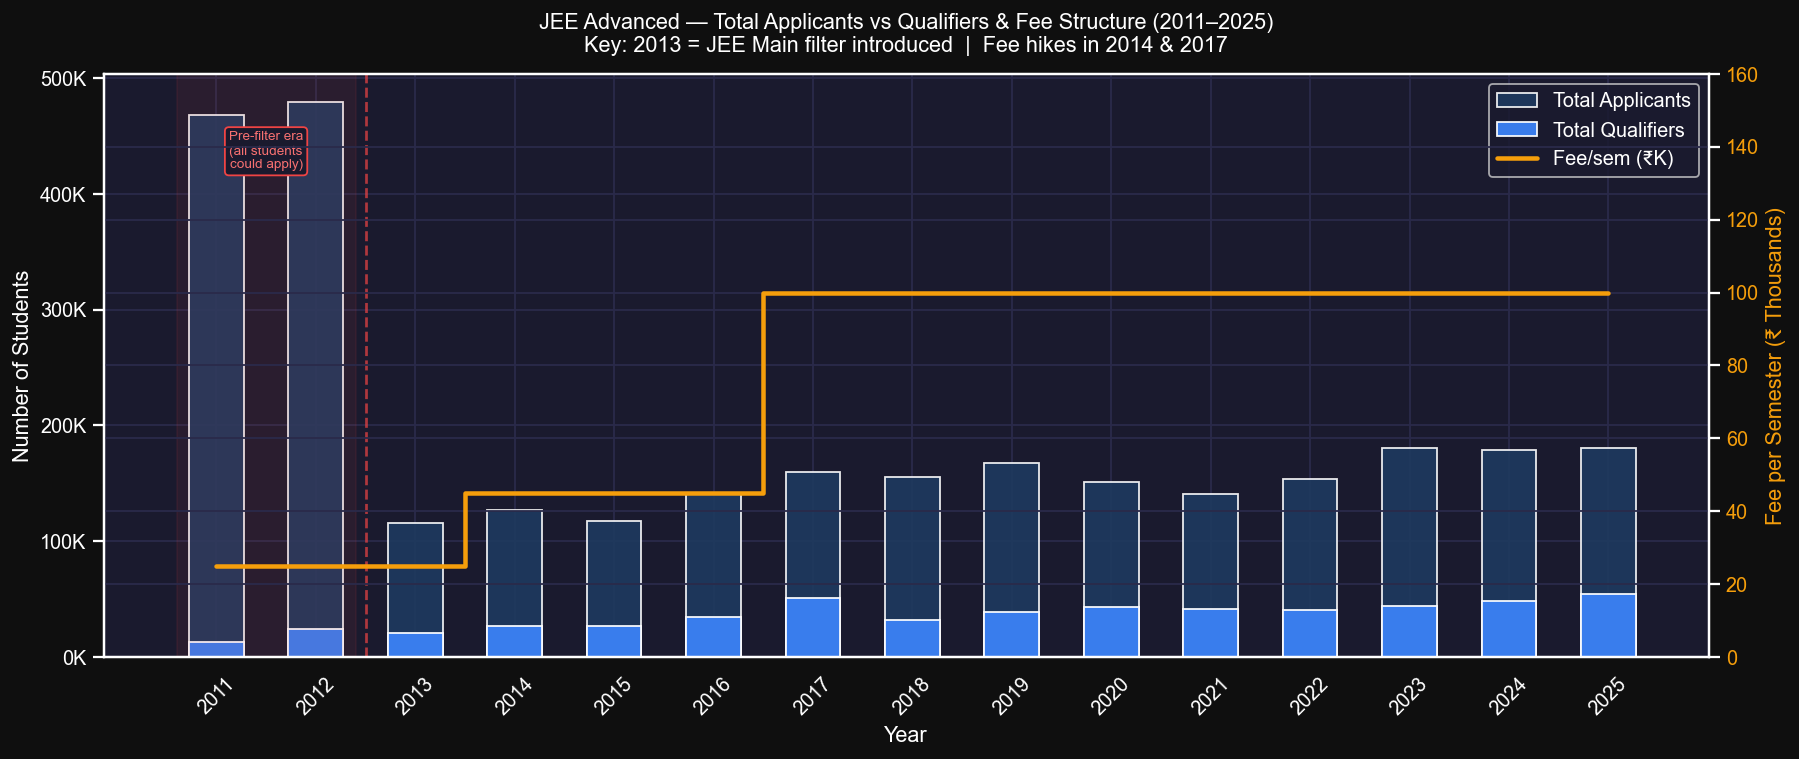

In [4]:
# Exclude 2011-2012 outliers for scale clarity — show separately
df_post = df[df["Year"] >= 2013].copy()
df_pre  = df[df["Year"] <  2013].copy()

fig, ax1 = plt.subplots(figsize=(14, 6))

# Bars — applicants
ax1.bar(df["Year"], df["app_Total"], width=0.55,
        color="#1e3a5f", label="Total Applicants", alpha=0.9)
ax1.bar(df["Year"], df["qual_Total"], width=0.55,
        color="#3b82f6", label="Total Qualifiers", alpha=0.95)

# Annotate 2011-2012 structural break
ax1.axvspan(2010.6, 2012.4, alpha=0.08, color="#ef4444")
ax1.text(2011.5, df["app_Total"].max() * 0.88,
         "Pre-filter era\n(all students\ncould apply)",
         ha="center", fontsize=7.5, color="#f87171",
         bbox=dict(boxstyle="round,pad=0.3", facecolor="#1a1a2e", edgecolor="#ef4444"))

# Axvline 2013 break
ax1.axvline(2012.5, color="#ef4444", linewidth=1.5, linestyle="--", alpha=0.7)

# Fee as step line on secondary axis
ax2 = ax1.twinx()
ax2.step(df["Year"], df["Fee"] / 1000, where="mid",
         color="#f59e0b", linewidth=2.5, linestyle="-", label="Fee/sem (₹K)")
ax2.set_ylabel("Fee per Semester (₹ Thousands)", color="#f59e0b")
ax2.tick_params(axis="y", labelcolor="#f59e0b")
ax2.set_ylim(0, 160)

ax1.set_title("JEE Advanced — Total Applicants vs Qualifiers & Fee Structure (2011–2025)\n"
              "Key: 2013 = JEE Main filter introduced  |  Fee hikes in 2014 & 2017",
              fontsize=12, pad=12)
ax1.set_xlabel("Year")
ax1.set_ylabel("Number of Students")
ax1.set_xticks(df["Year"])
ax1.set_xticklabels(df["Year"], rotation=45)
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f"{int(x/1000)}K"))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc="upper right")

plt.tight_layout()
plt.savefig("21_applicants_qualifiers_fee.png", bbox_inches="tight")
plt.show()

In [6]:
import plotly.graph_objects as go

fig = go.Figure()

# Bars — applicants
fig.add_trace(go.Bar(
    x=df["Year"],
    y=df["app_Total"],
    name="Total Applicants",
    marker_color="#1e3a5f",
    opacity=0.9
))

fig.add_trace(go.Bar(
    x=df["Year"],
    y=df["qual_Total"],
    name="Total Qualifiers",
    marker_color="#3b82f6",
    opacity=0.95
))

# Fee line (secondary axis)
fig.add_trace(go.Scatter(
    x=df["Year"],
    y=df["Fee"] / 1000,
    name="Fee/sem (₹K)",
    mode="lines+markers",
    line=dict(color="#f59e0b", width=2.5),
    yaxis="y2"
))

# Highlight 2011–2012 region
fig.add_vrect(
    x0=2010.6, x1=2012.4,
    fillcolor="#ef4444",
    opacity=0.08,
    layer="below",
    line_width=0
)

# Vertical line at 2013 break
fig.add_vline(
    x=2012.5,
    line=dict(color="#ef4444", width=1.5, dash="dash")
)

# Annotation
fig.add_annotation(
    x=2011.5,
    y=df["app_Total"].max() * 0.88,
    text="Pre-filter era<br>(all students<br>could apply)",
    showarrow=False,
    font=dict(size=10, color="#f87171"),
    bgcolor="#1a1a2e",
    bordercolor="#ef4444",
    borderwidth=1
)

# Layout
fig.update_layout(
    title="JEE Advanced — Total Applicants vs Qualifiers & Fee Structure (2011–2025)<br>"
          "Key: 2013 = JEE Main filter introduced  |  Fee hikes in 2014 & 2017",
    xaxis=dict(
        title="Year",
        tickmode="array",
        tickvals=df["Year"],
        tickangle=45
    ),
    yaxis=dict(
        title="Number of Students",
        tickformat=","
    ),
    yaxis2=dict(
        title="Fee per Semester (₹ Thousands)",
        overlaying="y",
        side="right",
        range=[0, 160]
    ),
    barmode="overlay",  # same overlap feel as matplotlib
    legend=dict(x=0.8, y=1),
    template="plotly_dark",
    height=500
)
fig.write_html("21_applicants_qualifiers_fee.html")
fig.show()

BLOCK 3 — PLOT 2: Category-wise Selection Rate Over Years

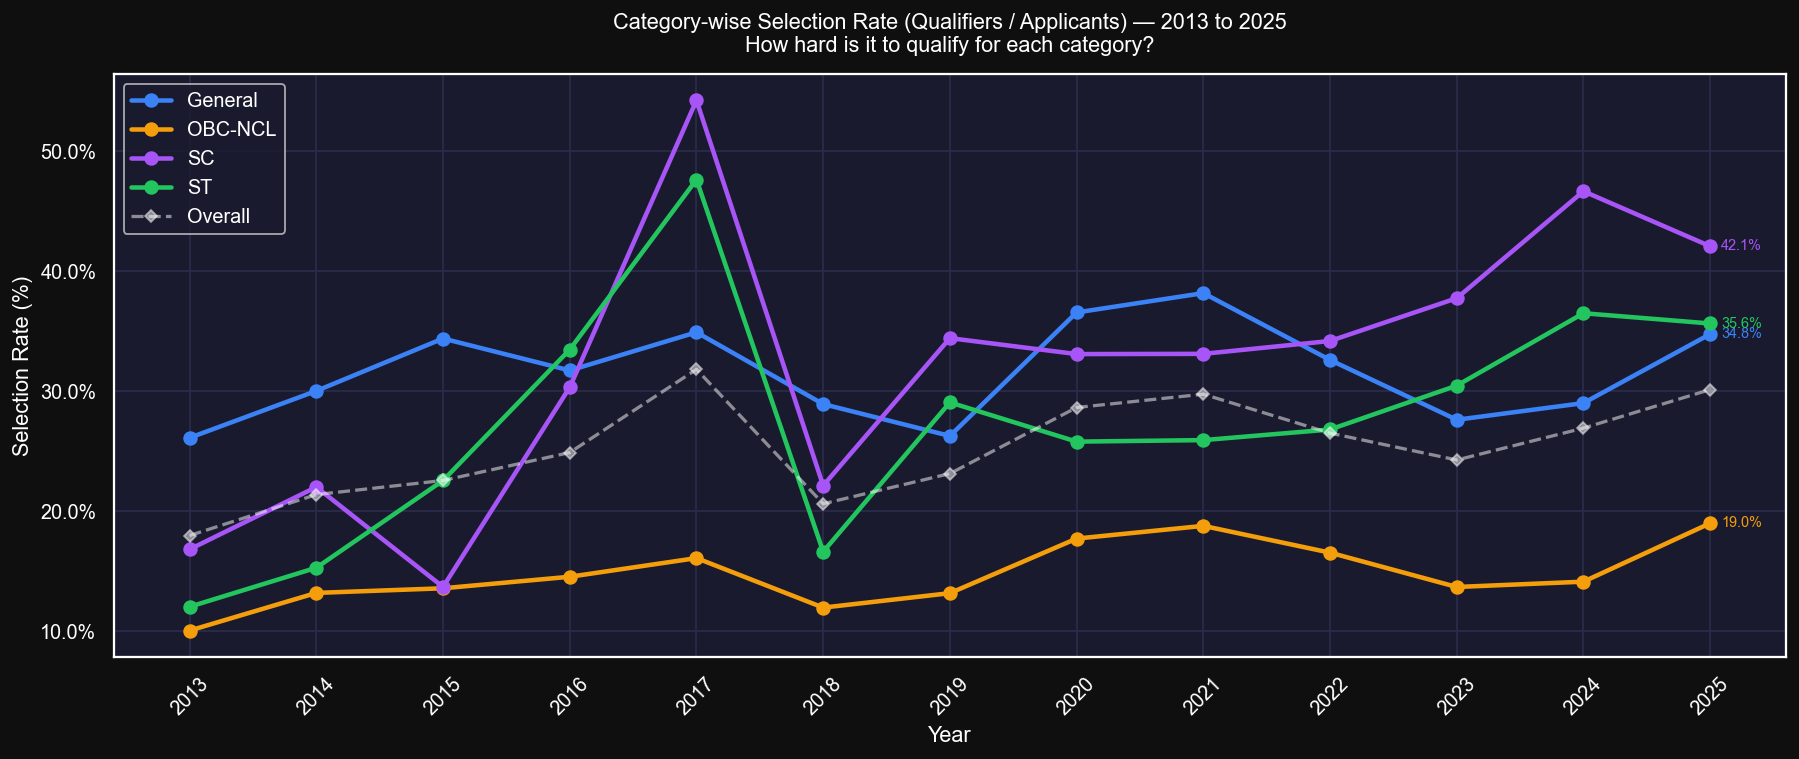

In [7]:
fig, ax = plt.subplots(figsize=(14, 6))

cats = [("sr_Gen","#3b82f6","General"),
        ("sr_OBC","#f59e0b","OBC-NCL"),
        ("sr_SC", "#a855f7","SC"),
        ("sr_ST", "#22c55e","ST")]

# Use only post-2013 for meaningful comparison (pre-2013 different base pool)
df_plot = df[df["Year"] >= 2013]

for col, color, label in cats:
    ax.plot(df_plot["Year"], df_plot[col], marker="o", linewidth=2.5,
            markersize=7, color=color, label=label)
    # Annotate last point
    last = df_plot.iloc[-1]
    ax.annotate(f"{last[col]:.1f}%",
                xy=(last["Year"], last[col]),
                xytext=(6, 0), textcoords="offset points",
                fontsize=8, color=color, va="center")

# Overall selection rate
ax.plot(df_plot["Year"], df_plot["sr_Overall"], marker="D", linewidth=1.8,
        markersize=5, color="white", linestyle="--", alpha=0.5, label="Overall")

ax.set_title("Category-wise Selection Rate (Qualifiers / Applicants) — 2013 to 2025\n"
             "How hard is it to qualify for each category?", fontsize=12, pad=12)
ax.set_xlabel("Year")
ax.set_ylabel("Selection Rate (%)")
ax.set_xticks(df_plot["Year"])
ax.set_xticklabels(df_plot["Year"], rotation=45)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f%%"))
ax.legend(loc="upper left")

plt.tight_layout()
plt.savefig("22_category_selection_rate.png", bbox_inches="tight")
plt.show()

BLOCK 4 — PLOT 3: Category Share in Qualifiers Over Time

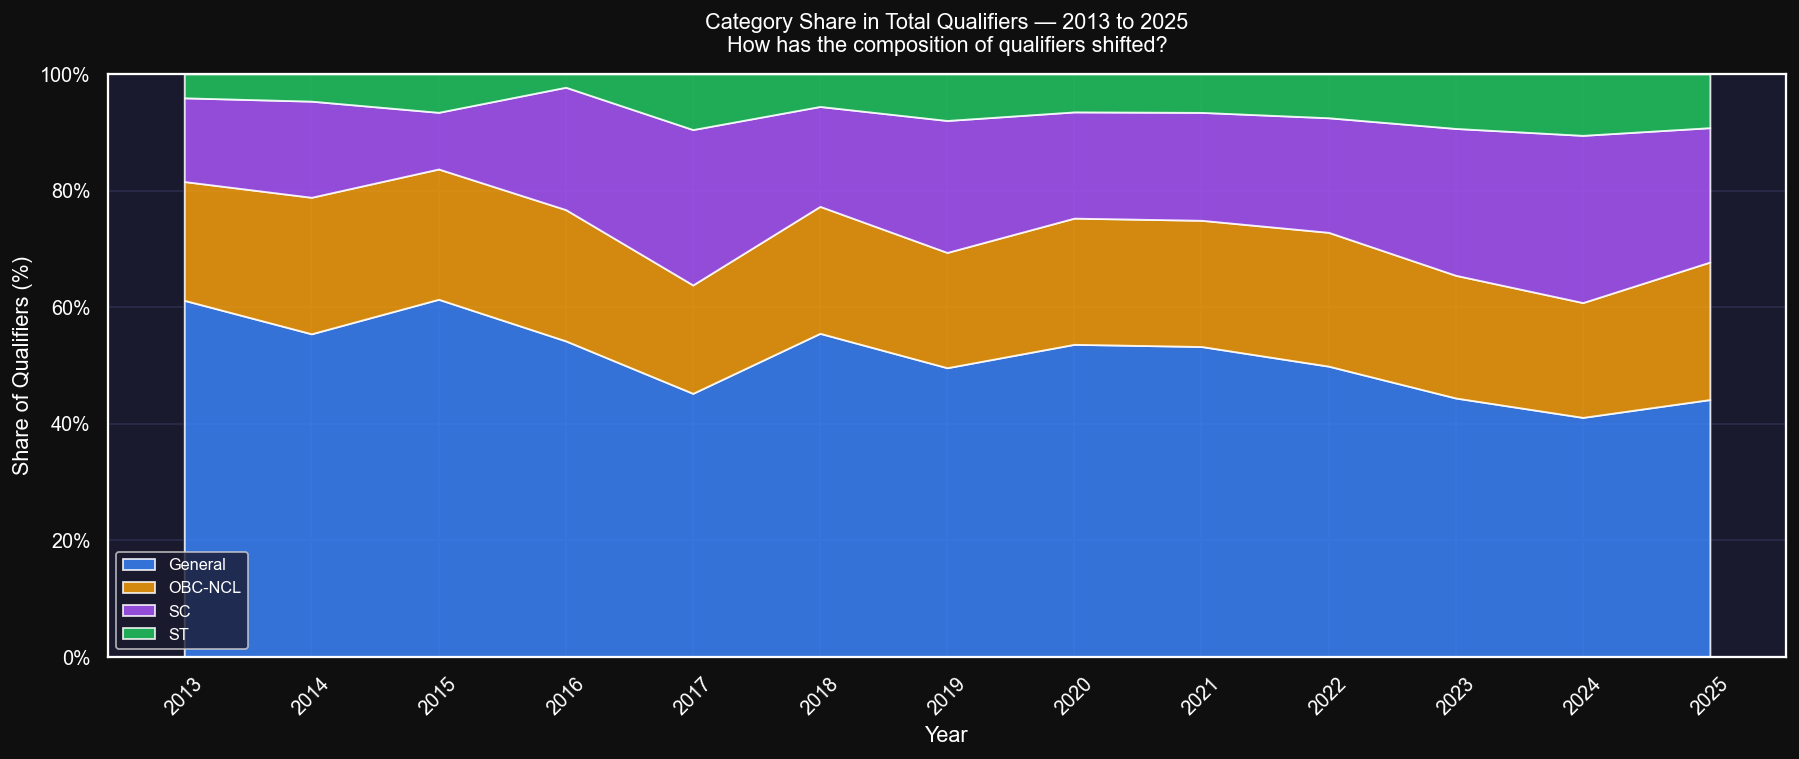

In [8]:
fig, ax = plt.subplots(figsize=(14, 6))

df_plot = df[df["Year"] >= 2013].copy()
total_q = df_plot[["qual_Gen","qual_OBC","qual_SC","qual_ST"]].sum(axis=1)

gen_pct = df_plot["qual_Gen"] / total_q * 100
obc_pct = df_plot["qual_OBC"] / total_q * 100
sc_pct  = df_plot["qual_SC"]  / total_q * 100
st_pct  = df_plot["qual_ST"]  / total_q * 100

ax.stackplot(df_plot["Year"],
             gen_pct, obc_pct, sc_pct, st_pct,
             labels=["General","OBC-NCL","SC","ST"],
             colors=["#3b82f6","#f59e0b","#a855f7","#22c55e"],
             alpha=0.85)

ax.set_title("Category Share in Total Qualifiers — 2013 to 2025\n"
             "How has the composition of qualifiers shifted?", fontsize=12, pad=12)
ax.set_xlabel("Year")
ax.set_ylabel("Share of Qualifiers (%)")
ax.set_xticks(df_plot["Year"])
ax.set_xticklabels(df_plot["Year"], rotation=45)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.0f%%"))
ax.legend(loc="lower left", fontsize=9)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig("23_qualifier_composition.png", bbox_inches="tight")
plt.show()

BLOCK 5 — PLOT 4: Absolute Qualifier Growth — Category-wise Bar Race Style

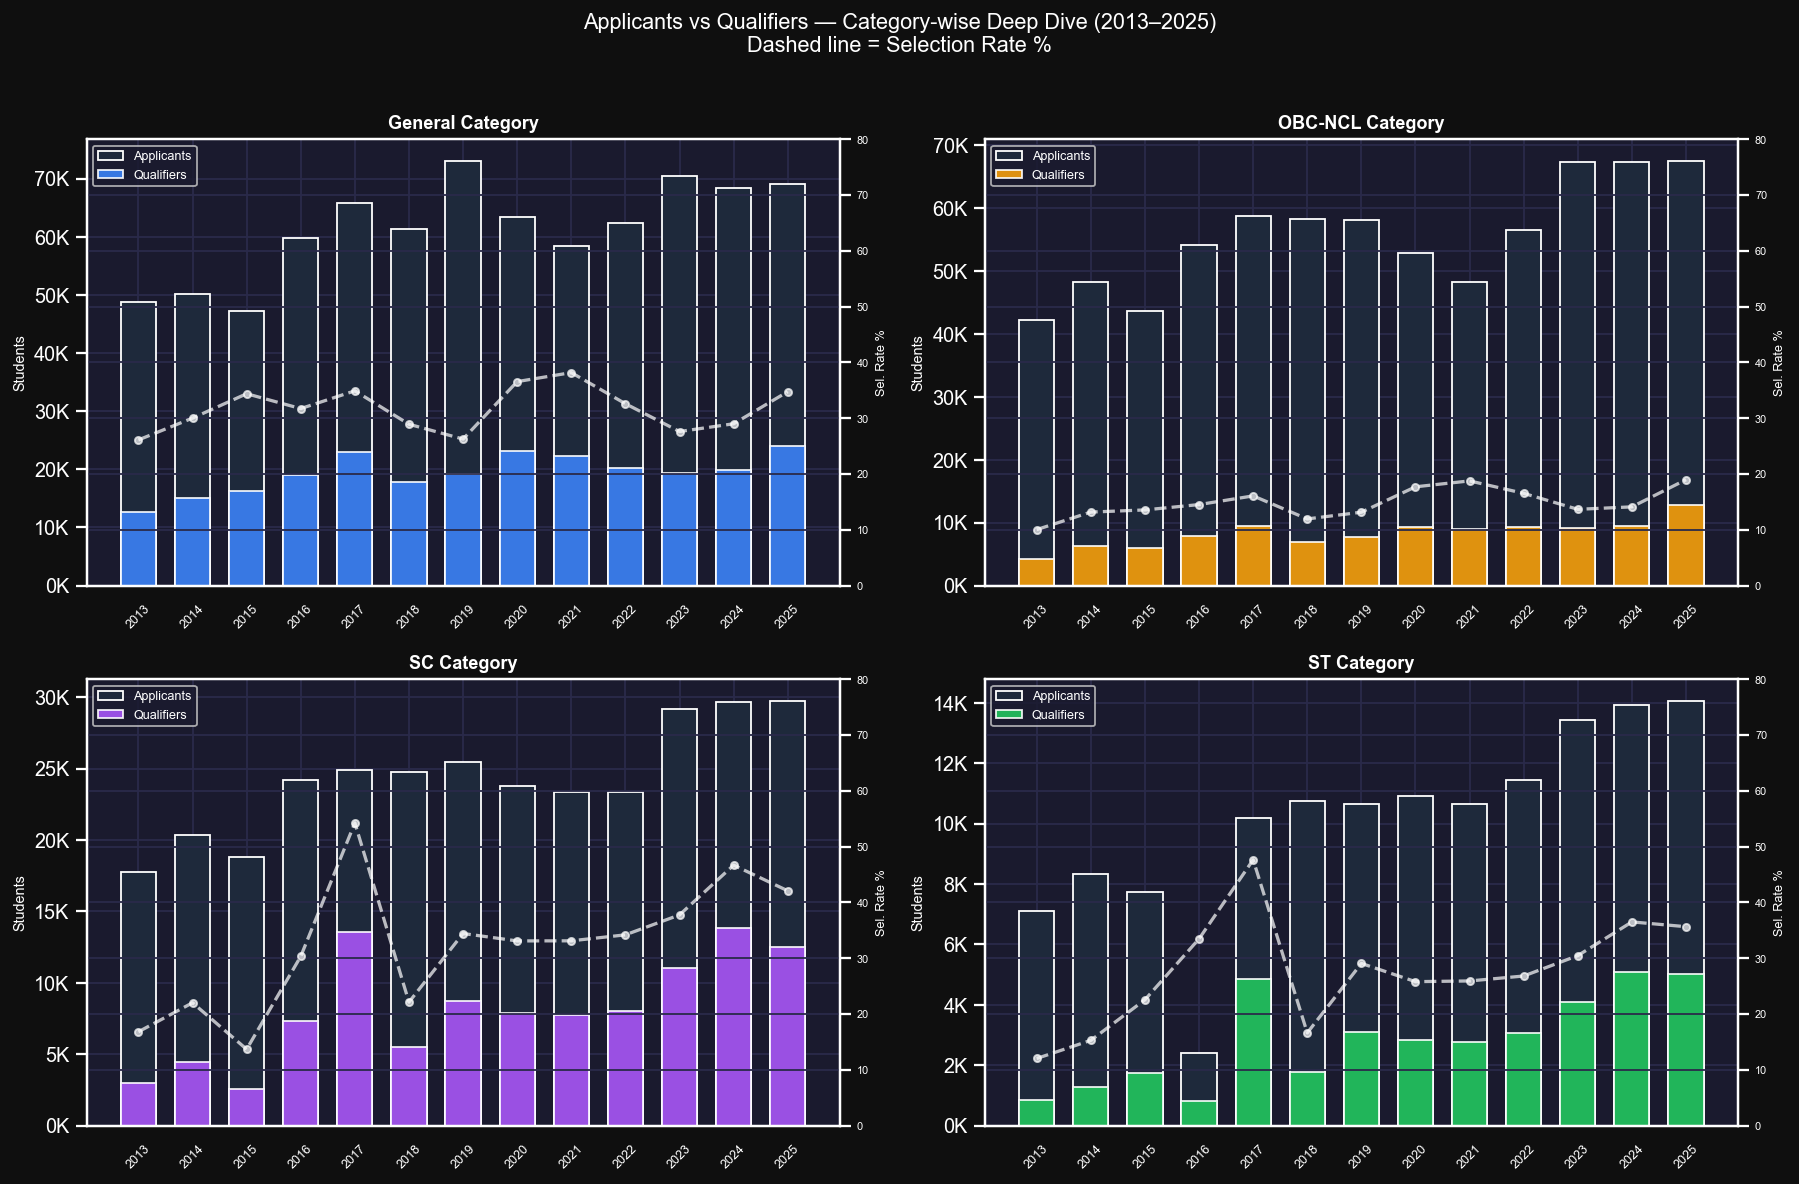

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

cats_data = [
    ("qual_Gen", "app_Gen", "#3b82f6", "General"),
    ("qual_OBC", "app_OBC", "#f59e0b", "OBC-NCL"),
    ("qual_SC",  "app_SC",  "#a855f7", "SC"),
    ("qual_ST",  "app_ST",  "#22c55e", "ST"),
]

df_plot = df[df["Year"] >= 2013]

for ax, (qcol, acol, color, label) in zip(axes, cats_data):
    ax.bar(df_plot["Year"], df_plot[acol],  color="#1e293b", width=0.65, label="Applicants")
    ax.bar(df_plot["Year"], df_plot[qcol],  color=color,    width=0.65, label="Qualifiers", alpha=0.9)

    # Selection rate line on secondary axis
    ax2 = ax.twinx()
    sr = (df_plot[qcol] / df_plot[acol]) * 100
    ax2.plot(df_plot["Year"], sr, color="white", linewidth=1.8,
             linestyle="--", marker="o", markersize=4, alpha=0.7)
    ax2.set_ylabel("Sel. Rate %", fontsize=7, color="white")
    ax2.tick_params(axis="y", labelsize=6, labelcolor="white")
    ax2.set_ylim(0, 80)

    ax.set_title(f"{label} Category", fontsize=10, fontweight="bold")
    ax.set_xticks(df_plot["Year"])
    ax.set_xticklabels(df_plot["Year"], rotation=45, fontsize=7)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f"{int(x/1000)}K"))
    ax.set_ylabel("Students", fontsize=8)
    ax.legend(fontsize=7, loc="upper left")

fig.suptitle("Applicants vs Qualifiers — Category-wise Deep Dive (2013–2025)\n"
             "Dashed line = Selection Rate %", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("24_category_deepdive.png", bbox_inches="tight")
plt.show()

BLOCK 6 — PLOT 5: Equity Index — How Far Are Reserved Categories From Parity?

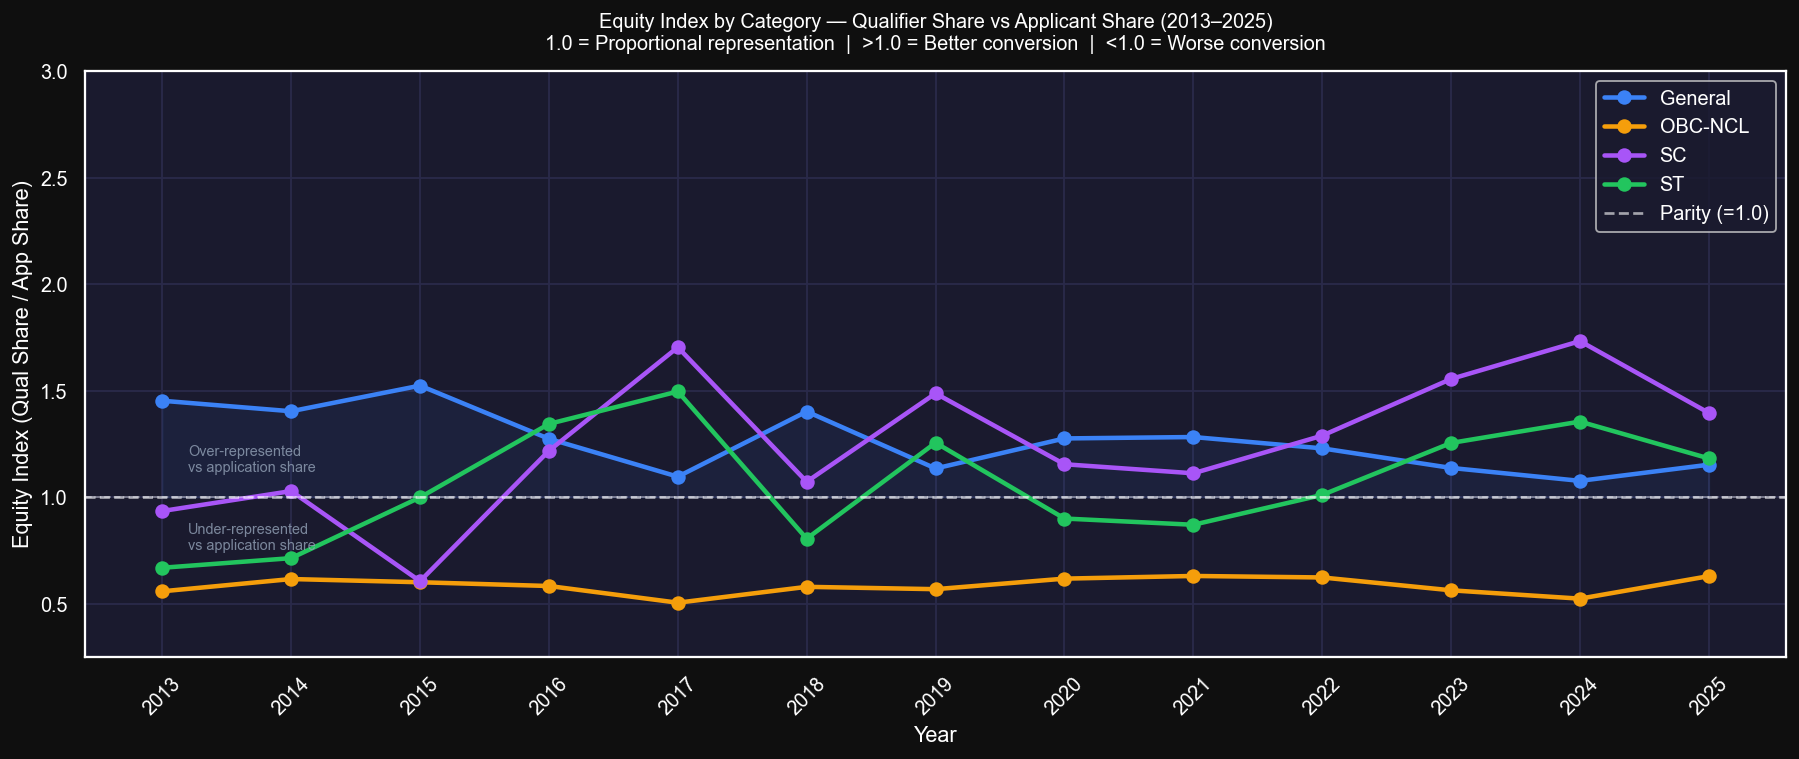

In [14]:
# Equity Index: (Category qual share) / (Category app share)
# = 1.0 means perfect proportional representation
# > 1.0 means over-represented in qualifiers vs applicants (reservation working beyond proportional)
# < 1.0 means under-represented

df_plot = df[df["Year"] >= 2013].copy()
total_app = df_plot[["app_Gen","app_OBC","app_SC","app_ST"]].sum(axis=1)
total_qua = df_plot[["qual_Gen","qual_OBC","qual_SC","qual_ST"]].sum(axis=1)

for cat, qcol, acol in [("Gen","qual_Gen","app_Gen"),
                         ("OBC","qual_OBC","app_OBC"),
                         ("SC", "qual_SC", "app_SC"),
                         ("ST", "qual_ST", "app_ST")]:
    app_share  = df_plot[acol] / total_app
    qual_share = df_plot[qcol] / total_qua
    df_plot[f"equity_{cat}"] = qual_share / app_share

fig, ax = plt.subplots(figsize=(14, 6))

cats_eq = [("equity_Gen","#3b82f6","General"),
           ("equity_OBC","#f59e0b","OBC-NCL"),
           ("equity_SC", "#a855f7","SC"),
           ("equity_ST", "#22c55e","ST")]

for col, color, label in cats_eq:
    ax.plot(df_plot["Year"], df_plot[col], marker="o", linewidth=2.5,
            markersize=7, color=color, label=label)

# Parity line
ax.axhline(1.0, color="white", linewidth=1.5, linestyle="--", alpha=0.6, label="Parity (=1.0)")
ax.fill_between(df_plot["Year"], 1.0, df_plot["equity_Gen"],
                alpha=0.07, color="#3b82f6")

# Shade zones
ax.text(2013.2, 1.12, "Over-represented\nvs application share",
        fontsize=8, color="#94a3b8", alpha=0.8)
ax.text(2013.2, 0.88, "Under-represented\nvs application share",
        fontsize=8, color="#94a3b8", alpha=0.8, va="top")

ax.set_title("Equity Index by Category — Qualifier Share vs Applicant Share (2013–2025)\n"
             "1.0 = Proportional representation  |  >1.0 = Better conversion  |  <1.0 = Worse conversion",
             fontsize=11, pad=12)
ax.set_xlabel("Year")
ax.set_ylabel("Equity Index (Qual Share / App Share)")
ax.set_xticks(df_plot["Year"])
ax.set_xticklabels(df_plot["Year"], rotation=45)
ax.set_ylim(0.6, 1.5)
ax.legend(loc="upper right")
ax.axhline(1.0, color="white", linewidth=1, linestyle="--", alpha=0.4)

plt.ylim(0.25,3)
plt.tight_layout()
plt.savefig("25_equity_index.png", bbox_inches="tight")
plt.show()